<a href="https://colab.research.google.com/github/belokonr/ECON5200-Applied-Data-Analytics-in-Economics/blob/main/hw2/Econ_5200_Assignment_2_Audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as plt

# Phase 1: The Robustness Audit

In [ ]:
# Simulate the Data Generating Process (DGP) for a skewed system
# Manual DGP Simulation
normal_traffic = np.random.randint(20, 50, 980)
spike_traffic = np.random.randint(1000, 5000, 20)
latency_logs = np.concatenate([normal_traffic, spike_traffic])

In [ ]:
def calculate_mad(data):
    # 1. Calculate the Median of the data
    # 2. Calculate Absolute Deviations (|x - median|)
    # 3. Return the Median of those deviations
    median_data = np.median(data)
    abs_devs = abs(data - median_data)
    med_dev = np.median(abs_devs)
    return med_dev

In [ ]:
# Compare SD and MAD

print('Standard Deviation of Latency Logs:', np.std(latency_logs))

print('\nMedian Absolute Deviation of Latency Logs:', calculate_mad(latency_logs))

Standard Deviation of Latency Logs: 529.5046787933039

Median Absolute Deviation of Latency Logs: 8.0


Standard deviation is calculated by taking an average of the deviations of each data point from the mean, whereas MAD takes the median of those deviations. The MAD thus gets a better idea of what the midpoint deviation is, as there are only 20 huge outliers at the end but the median comes from the 500th absolute deviation. The SD meanwhile is immediately pulled up by the 20 huge deviations from 980-1000.

# Phase 2: The Probability Audit

In [10]:
def bayesian_audit(prior, sensitivity=0.98, specificity=0.98):

  denom = (sensitivity * prior) + ((1-specificity) * (1-prior))

  bayes = (sensitivity * prior) / denom

  return bayes


In [13]:
#Test Scenario A
print("Test A Pr(Cheater|Flagged):", bayesian_audit(0.5))
print("Test B Pr(Cheater|Flagged):", bayesian_audit(0.05))
print("Test C Pr(Cheater|Flagged):", bayesian_audit(0.001))

Test A Pr(Cheater|Flagged): 0.98
Test B Pr(Cheater|Flagged): 0.7205882352941175
Test C Pr(Cheater|Flagged): 0.04675572519083965


In reality, for a 98% accurate plagiarism detector, the probability of a flagged assignment being a true instance of cheating is below 5% when cheating only happens 0.1% of the time.

# Phase 3: The Bias Audit

In [22]:
# Chi-Square Formula: Sum( (Observed - Expected)^2 / Expected )
observed = np.array([50250, 49750])
expected = np.array([50000, 50000])
# Write the calculation loop
chi_sq = 0

for i in range(len(observed)):
  num = (observed[i] - expected[i])**2
  chi_i = num/expected[i]
  chi_sq += chi_i

print("Chi-square:", chi_sq)


Chi-square: 2.5


The Chi-square is below 3.84 and so the experiment is not ruled invalid due to engineering bias.

# Phase 4: AI Expansion (The Co-Pilot Era)

   SURVIVORSHIP BIAS — CRYPTO TOKEN MARKET SIMULATION
  Tokens Launched        :     10,000
  Survivors (Top 1%)     :        100
  Dead Tokens (99%)      :      9,900
-----------------------------------------------------------------
  Metric                             All Tokens      Survivors
-----------------------------------------------------------------
  Mean Market Cap                $        6,585 $      264,591
  Median Market Cap              $        1,908 $      146,875
-----------------------------------------------------------------
  ⚠  Survivorship Bias Multiplier: 40.2x
     (Survivors' mean is 40.2x the true market mean)
     Looking only at winners inflates perceived returns by
     ~3,918%


/tmp/ipython-input-1347299971.py:124: UserWarning: Glyph 128128 (\N{SKULL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1347299971.py:124: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1347299971.py:125: UserWarning: Glyph 128128 (\N{SKULL}) missing from font(s) DejaVu Sans.
  plt.savefig("survivorship_bias_crypto.png", dpi=200, bbox_inches="tight",
/tmp/ipython-input-1347299971.py:125: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) DejaVu Sans.
  plt.savefig("survivorship_bias_crypto.png", dpi=200, bbox_inches="tight",
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128128 (\N{SKULL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_i

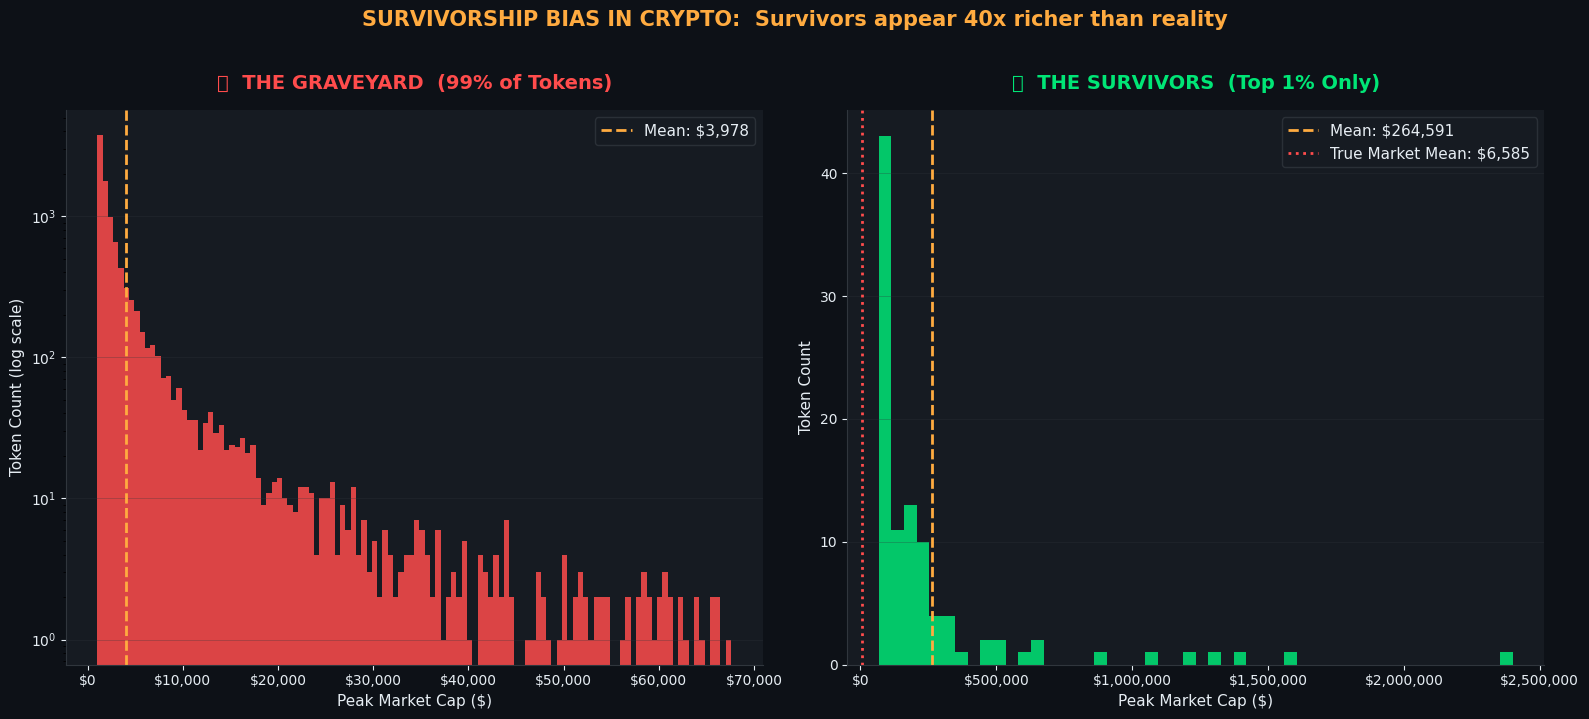


📊 Distribution Percentiles (All Tokens):
   P25    → $          1,309
   P50    → $          1,908
   P75    → $          3,607
   P90    → $          8,609
   P95    → $         16,533
   P99    → $         67,583
   P99.9  → $        528,667

   Max   → $      2,400,138
   Min   → $          1,000


In [23]:
"""
=============================================================================
  SURVIVORSHIP BIAS IN CRYPTO TOKEN MARKETS — Monte Carlo Simulation
  Author : Financial Data Scientist (simulation)
  Purpose: Demonstrate how looking only at "winners" distorts perceived reality
=============================================================================
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── Configuration ───────────────────────────────────────────────────────────
np.random.seed(42)
N_TOKENS        = 10_000          # Total token launches to simulate
PARETO_SHAPE    = 1.05            # α – lower = heavier tail (more extreme inequality)
PARETO_SCALE    = 1_000           # x_m – minimum market cap ($)
SURVIVOR_PCT    = 0.01            # Top 1% = "survivors"

# ── 1. SIMULATE TOKEN LAUNCHES ─────────────────────────────────────────────
# Pareto (Power Law) distribution: most tokens cluster near zero,
# a tiny fraction explode to massive market caps.
raw_caps = (np.random.pareto(PARETO_SHAPE, N_TOKENS) + 1) * PARETO_SCALE

# ── 2. BUILD DATAFRAMES ────────────────────────────────────────────────────
df_all = pd.DataFrame({
    "token_id":       np.arange(1, N_TOKENS + 1),
    "peak_market_cap": raw_caps,
    "status":          "dead"
})

# Determine survivor threshold (top 1%)
threshold = np.percentile(raw_caps, (1 - SURVIVOR_PCT) * 100)
df_all.loc[df_all["peak_market_cap"] >= threshold, "status"] = "survivor"

df_survivors = df_all[df_all["status"] == "survivor"].copy()
df_graveyard = df_all[df_all["status"] == "dead"].copy()

# ── 3. STATISTICAL SUMMARY ─────────────────────────────────────────────────
mean_all       = df_all["peak_market_cap"].mean()
median_all     = df_all["peak_market_cap"].median()
mean_survivors = df_survivors["peak_market_cap"].mean()
median_survivors = df_survivors["peak_market_cap"].median()
mean_graveyard = df_graveyard["peak_market_cap"].mean()

bias_multiplier = mean_survivors / mean_all

print("=" * 65)
print("   SURVIVORSHIP BIAS — CRYPTO TOKEN MARKET SIMULATION")
print("=" * 65)
print(f"  Tokens Launched        : {N_TOKENS:>10,}")
print(f"  Survivors (Top 1%)     : {len(df_survivors):>10,}")
print(f"  Dead Tokens (99%)      : {len(df_graveyard):>10,}")
print("-" * 65)
print(f"  {'Metric':<30} {'All Tokens':>14} {'Survivors':>14}")
print("-" * 65)
print(f"  {'Mean Market Cap':<30} ${mean_all:>13,.0f} ${mean_survivors:>13,.0f}")
print(f"  {'Median Market Cap':<30} ${median_all:>13,.0f} ${median_survivors:>13,.0f}")
print("-" * 65)
print(f"  ⚠  Survivorship Bias Multiplier: {bias_multiplier:,.1f}x")
print(f"     (Survivors' mean is {bias_multiplier:,.1f}x the true market mean)")
print(f"     Looking only at winners inflates perceived returns by")
print(f"     ~{(bias_multiplier - 1) * 100:,.0f}%")
print("=" * 65)

# ── 4. DUAL HISTOGRAM VISUALIZATION ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7), facecolor="#0d1117")

# --- Color Palette ---
C_DEAD     = "#ff4c4c"
C_SURVIVOR = "#00e676"
C_BG       = "#0d1117"
C_PANEL    = "#161b22"
C_TEXT     = "#e6edf3"
C_GRID     = "#30363d"

for ax in axes:
    ax.set_facecolor(C_PANEL)
    ax.tick_params(colors=C_TEXT, labelsize=10)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(C_GRID)
    ax.spines["bottom"].set_color(C_GRID)
    ax.grid(axis="y", color=C_GRID, alpha=0.4, linewidth=0.5)

# --- LEFT: The Graveyard (99%) — log scale ---
ax1 = axes[0]
ax1.hist(df_graveyard["peak_market_cap"], bins=120, color=C_DEAD,
         alpha=0.85, edgecolor="none", log=True)
ax1.axvline(mean_graveyard, color="#ffab40", ls="--", lw=2,
            label=f"Mean: ${mean_graveyard:,.0f}")
ax1.set_title("💀  THE GRAVEYARD  (99% of Tokens)", fontsize=14,
              fontweight="bold", color=C_DEAD, pad=15)
ax1.set_xlabel("Peak Market Cap ($)", color=C_TEXT, fontsize=11)
ax1.set_ylabel("Token Count (log scale)", color=C_TEXT, fontsize=11)
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax1.legend(fontsize=11, loc="upper right", facecolor=C_PANEL,
           edgecolor=C_GRID, labelcolor=C_TEXT)

# --- RIGHT: The Survivors (Top 1%) ---
ax2 = axes[1]
ax2.hist(df_survivors["peak_market_cap"], bins=50, color=C_SURVIVOR,
         alpha=0.85, edgecolor="none")
ax2.axvline(mean_survivors, color="#ffab40", ls="--", lw=2,
            label=f"Mean: ${mean_survivors:,.0f}")
ax2.axvline(mean_all, color="#ff4c4c", ls=":", lw=2,
            label=f"True Market Mean: ${mean_all:,.0f}")
ax2.set_title("🚀  THE SURVIVORS  (Top 1% Only)", fontsize=14,
              fontweight="bold", color=C_SURVIVOR, pad=15)
ax2.set_xlabel("Peak Market Cap ($)", color=C_TEXT, fontsize=11)
ax2.set_ylabel("Token Count", color=C_TEXT, fontsize=11)
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax2.legend(fontsize=11, loc="upper right", facecolor=C_PANEL,
           edgecolor=C_GRID, labelcolor=C_TEXT)

# --- Suptitle ---
fig.suptitle(
    f"SURVIVORSHIP BIAS IN CRYPTO:  Survivors appear {bias_multiplier:,.0f}x "
    f"richer than reality",
    fontsize=15, fontweight="bold", color="#ffab40", y=1.02
)

plt.tight_layout()
plt.savefig("survivorship_bias_crypto.png", dpi=200, bbox_inches="tight",
            facecolor=C_BG, edgecolor="none")
plt.show()

# ── 5. BONUS: Quick Distribution Summary ───────────────────────────────────
print("\n📊 Distribution Percentiles (All Tokens):")
for p in [25, 50, 75, 90, 95, 99, 99.9]:
    val = np.percentile(raw_caps, p)
    print(f"   P{p:<5} → ${val:>15,.0f}")
print(f"\n   Max   → ${raw_caps.max():>15,.0f}")
print(f"   Min   → ${raw_caps.min():>15,.0f}")